# Agents

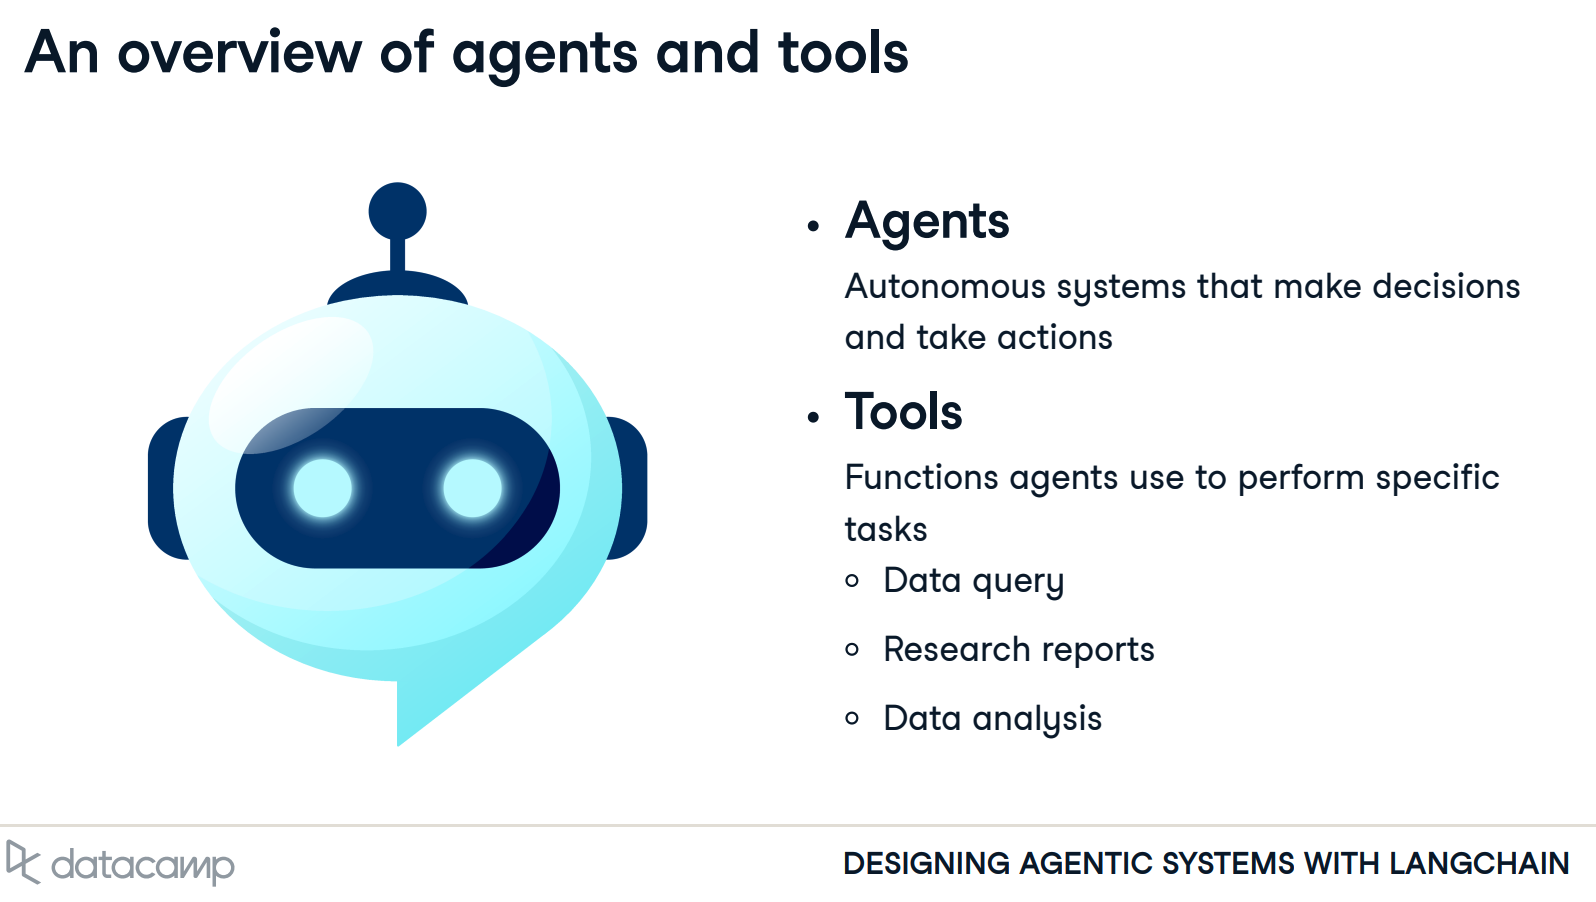

The Agent is at its core an LLM, which consumes tools to perform a task. In this course we will use Langchain, which is a Framework to build AI agents using components such as:

- LLMS
- Prompts
- Tools
- APIs

## ReAct Agents

Agents can Reason about a problem, then Act. This agentic framework is called ReAct

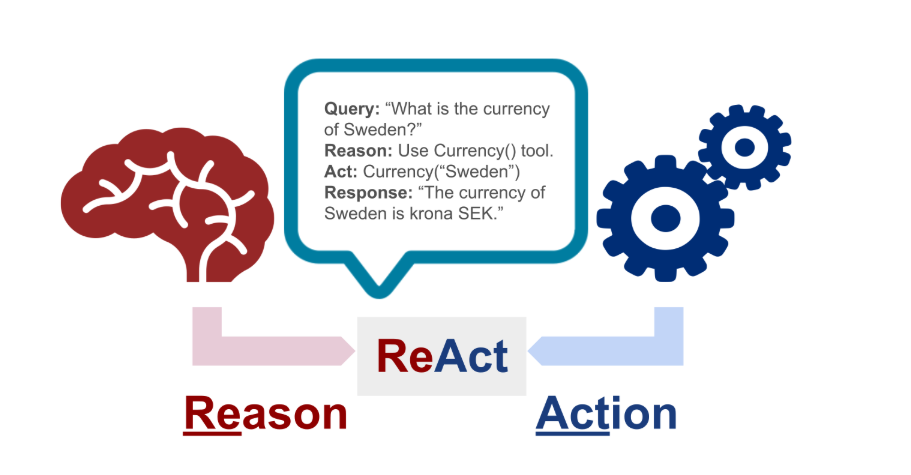

## Expanding agents with LangGraph

Langgrapgh can enhance tools even further by structuring tasks in workflows called graphs

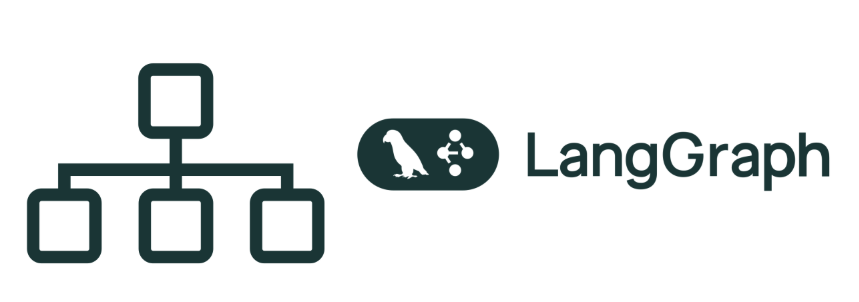

In these graphs

- The **tasks** are called **nodes**
- The **nodes** are connected by rules called **edges**

For example, A database query node identifies the correct document ID, saves it to the State, and an edge routes the workflow to the document retrieval node, which uses the ID from the State to fetch the text.

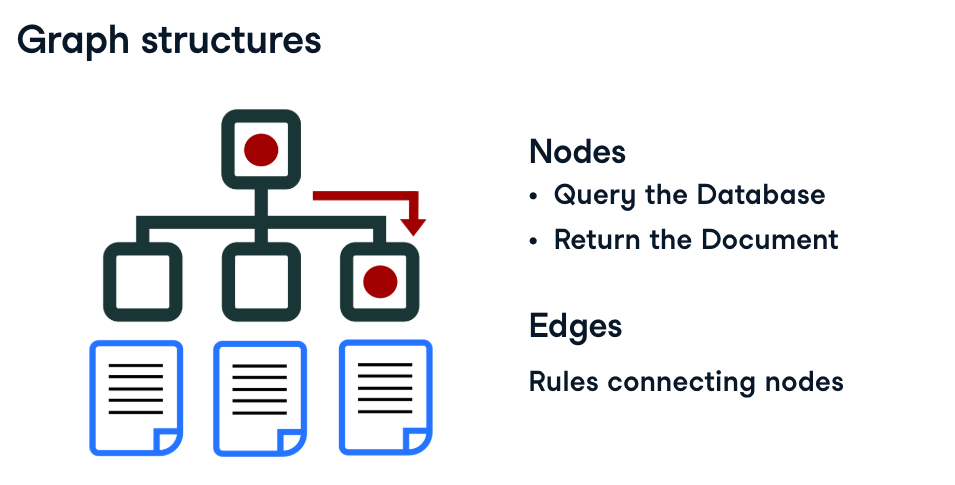

In [1]:
import os
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain_core.tools import tool
from langchain.agents import create_agent

# Load variables from .env into the system environment
load_dotenv() 

# LangChain automatically detects "ANTHROPIC_API_KEY" from the environment
model = ChatAnthropic(model="claude-haiku-4-5")

# Define the tool
@tool
def calculator(expression: str) -> str:
    """
    Evaluates a mathematical expression string and returns the result.
    Useful for solving math problems like (2+8)*9.
    """
    try:
        # Note: In production, use a safer math library than eval()
        return str(eval(expression))
    except Exception as e:
        return f"Error: {str(e)}"

# Put the tool in a list
tools = [calculator]

# Create the agent
agent = create_agent(model, tools)

# Create a query
query = "What is (2+8) multiplied by 9?"
response = agent.invoke({"messages": [("human", query)]})

# Print the response
print(response['messages'][-1].content)

(2+8) multiplied by 9 equals **90**.

Here's the breakdown:
- 2 + 8 = 10
- 10 × 9 = 90


did it actually use the tool? let's see

In [3]:
from pprint import pprint

# This will print the response dictionary with nice indentation
pprint(response)

{'messages': [HumanMessage(content='What is (2+8) multiplied by 9?', additional_kwargs={}, response_metadata={}, id='620262bf-87ce-4b5e-b9fa-8f890e244a6a'),
              AIMessage(content=[{'id': 'toolu_01NefeK73ZaFsdKohQHYbLX5', 'caller': {'type': 'direct'}, 'input': {'expression': '(2+8)*9'}, 'name': 'calculator', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01Kwbfj7Y7P3a4PiqNgWRESW', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 588, 'output_tokens': 57, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019cc145-8d26-7893-9523-b43de9380ac9-0', tool_calls=[{'name': 'calculator', 'args': {'expression':

# Building Custom Tools

Note that for a tool to be usable by an LLM it has to contain some main parts:

### 1. The Name (The Identifier)

The name should be **unique and semantic**. The LLM uses the name as a quick reference.

* **Bad:** `func1`, `get_data`, `run_query`.
* **Good:** `get_weather_forecast`, `query_customer_database`, `calculate_mortgage_payment`.
* **Pro Tip:** Use underscores or CamelCase consistently, and make it sound like an action.

### 2. The Description (The "Instruction Manual")

This is the most critical part. The LLM reads this to decide **if** it should use the tool. If your agent isn't calling a tool when it should, your description is likely too vague.

* **What to include:**
* **Purpose:** What does this tool actually do?
* **When to use it:** "Use this tool when the user asks for historical stock prices..."
* **When NOT to use it:** "...do not use this for real-time price alerts."
* **Output format:** Tell the LLM what kind of data it will get back (e.g., "Returns a JSON list of products").



### 3. The Input Schema (The Arguments)

In LangChain, this is usually defined via **Pydantic** or a **JSON Schema**. You must be explicit about the data types.

* **Parameter Names:** Should be descriptive (e.g., `zip_code` instead of `z`).
* **Parameter Descriptions:** Describe what each argument expects. For example, if a date is required, specify the format: `"date (YYYY-MM-DD)"`.
* **Required vs. Optional:** Clearly define which fields the LLM *must* provide and which have default values.

### 4. The Output (The Observation)

What the function returns is what the agent "sees" next.

* **Text-Friendly:** LLMs process text best. If your function returns a massive, messy Python object, the agent might get confused or run out of tokens.
* **Error Handling:** If the tool fails (e.g., a 404 error from an API), return a **descriptive error string** like `"Error: Customer ID not found. Please verify the ID and try again."` rather than just crashing the code. This allows the agent to "reason" about the error and potentially try a different approach.

In [ ]:
import math
from langchain.tools import tool
from pydantic import BaseModel, Field

# 1. Define the Input Schema (The "Arguments")
class HypotenuseInput(BaseModel):
    side_a: float = Field(description="The length of the first leg of the right triangle.")
    side_b: float = Field(description="The length of the second leg of the right triangle.")

# 2. Define the Tool with a clear Name and Description
@tool("calculate_hypotenuse", args_schema=HypotenuseInput)
def calculate_hypotenuse(side_a: float, side_b: float) -> str:
    """
    Calculates the length of the hypotenuse for a right-angled triangle 
    given the lengths of the other two sides (legs).
    Use this tool whenever a user asks for the longest side of a right triangle.
    """
    try:
        # 3. The Logic (The "Action")
        hypotenuse = math.sqrt(side_a**2 + side_b**2)
        
        # 4. The Output (The "Observation")
        return f"The hypotenuse is {hypotenuse:.2f}"
    except Exception as e:
        return f"Error calculating hypotenuse: {str(e)}"
    
tools = [calculate_hypotenuse]

# Create the agent
agent = create_agent(model, tools)

# Create a query
query = "What is the hypotenuse length of a triangle with side lengths of 10 and 12?"
response = agent.invoke({"messages": [("human", query)]})

# Print the response
print(response['messages'][-1].content)

The hypotenuse length of a right triangle with side lengths of 10 and 12 is **15.62** units.

This is calculated using the Pythagorean theorem: c² = a² + b², where c is the hypotenuse. In this case: c² = 10² + 12² = 100 + 144 = 244, so c = √244 ≈ 15.62.


In [ ]:
from IPython.display import JSON

# This creates an interactive tree in your Jupyter cell
JSON(response)

<IPython.core.display.JSON object>

# langchain version

In [ ]:
pip show langchain

Name: langchain
Version: 1.2.10
Summary: Building applications with LLMs through composability
Home-page: https://docs.langchain.com/
Author: 
Author-email: 
License: MIT
Location: /Users/martinalvarez/ds-ml-ai-learning/Designing Agentic Systems/venv/lib/python3.13/site-packages
Requires: langchain-core, langgraph, pydantic
Required-by: 
Note: you may need to restart the kernel to use updated packages.
